In [28]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [29]:
# Importing  required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
# Loading the dataset

df = pd.read_csv("Leads.csv")

In [31]:
# Having a look at the first 10 rows

df.head(10)

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified
5,2058ef08-2858-443e-a01f-a9237db2f5ce,660680,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,NaN,NaN,01.High,02.Medium,17.0,15.0,No,No,Modified
6,9fae7df4-169d-489b-afe4-0f3d752542ed,660673,Landing Page Submission,Google,No,No,1,2.0,1640,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,No,Modified
7,20ef72a2-fb3b-45e0-924e-551c5fa59095,660664,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Modified
8,cfa0128c-a0da-4656-9d47-0aa4e67bf690,660624,Landing Page Submission,Direct Traffic,No,No,0,2.0,71,2.0,...,No,NaN,Thane & Outskirts,02.Medium,02.Medium,14.0,14.0,No,Yes,Email Opened
9,af465dfc-7204-4130-9e05-33231863c4b5,660616,API,Google,No,No,0,4.0,58,4.0,...,No,NaN,Mumbai,02.Medium,02.Medium,13.0,16.0,No,No,Email Opened


In [32]:
# Checking the numbers of rows and columns

df.shape

(9240, 37)

In [33]:
# Columns wise information about dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [34]:
# Finding out the percentage of null values for every column

100 * df.isnull().sum()/len(df)

,0
Prospect ID,0.000000
Lead Number,0.000000
Lead Origin,0.000000
Lead Source,0.389610
Do Not Email,0.000000
Do Not Call,0.000000
Converted,0.000000
TotalVisits,1.482684
Total Time Spent on Website,0.000000
Page Views Per Visit,1.482684


In [35]:
# Dropping columns that wont add value to the final model

df.drop(columns=['Prospect ID', 'Lead Number', 'Lead Quality', 'Lead Profile', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index', 'Asymmetrique Activity Score', 'Asymmetrique Profile Score'], inplace=True)

In [36]:
# Filling missing values of some columns with median

df['TotalVisits'].fillna(df['TotalVisits'].median(), inplace=True)
df['Page Views Per Visit'].fillna(df['Page Views Per Visit'].median(), inplace=True)

In [37]:
# Filling missing values of some categorical columns with Not Provided

categorical_with_nulls = ['Specialization', 'What is your current occupation', 'City', 'Tags', 'Country', 'How did you hear about X Education', 'What matters most to you in choosing a course' ]
for col in categorical_with_nulls:
    df[col].fillna('Not Provided', inplace=True)

In [38]:
df['Lead Source'].value_counts()

,count
Lead Source,
Google,2868
Direct Traffic,2543
Olark Chat,1755
Organic Search,1154
Reference,534
Welingak Website,142
Referral Sites,125
Facebook,55
bing,6


In [39]:
df['Lead Source'].isnull().sum()

np.int64(36)

In [40]:
# Imputing Lead Source null values with the highest count

df['Lead Source'].fillna(df['Lead Source'].mode()[0], inplace=True)

In [41]:
df['Last Activity'].value_counts()

,count
Last Activity,
Email Opened,3437
SMS Sent,2745
Olark Chat Conversation,973
Page Visited on Website,640
Converted to Lead,428
Email Bounced,326
Email Link Clicked,267
Form Submitted on Website,116
Unreachable,93


In [42]:
df['Last Activity'].isnull().sum()

np.int64(103)

In [43]:
df.dropna(subset=['Last Activity'], inplace=True)

In [44]:
def binary_map(X):
  return X.map({'Yes': 1, 'No': 0})

In [45]:
# The list of binary columns from the data dictionary
binary_cols = [
    'Do Not Email',
    'Search',
    'Magazine',
    'Newspaper Article',
    'X Education Forums',
    'Newspaper',
    'Digital Advertisement',
    'Through Recommendations',
    'Receive More Updates About Our Courses',
    'Update me on Supply Chain Content',
    'Get updates on DM Content',
    'I agree to pay the amount through cheque',
    'A free copy of Mastering The Interview'
]

# Apply your function across all these columns simultaneously
df[binary_cols] = df[binary_cols].apply(binary_map)

In [46]:
# We replace all instance of drop down placeholder 'Select' with 'Not Provided'

df.replace('Select', 'Not Provided', inplace=True)

In [47]:
df.columns.to_list()

['Lead Origin',
 'Lead Source',
 'Do Not Email',
 'Do Not Call',
 'Converted',
 'TotalVisits',
 'Total Time Spent on Website',
 'Page Views Per Visit',
 'Last Activity',
 'Country',
 'Specialization',
 'How did you hear about X Education',
 'What is your current occupation',
 'What matters most to you in choosing a course',
 'Search',
 'Magazine',
 'Newspaper Article',
 'X Education Forums',
 'Newspaper',
 'Digital Advertisement',
 'Through Recommendations',
 'Receive More Updates About Our Courses',
 'Tags',
 'Update me on Supply Chain Content',
 'Get updates on DM Content',
 'City',
 'I agree to pay the amount through cheque',
 'A free copy of Mastering The Interview',
 'Last Notable Activity']

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9137 entries, 0 to 9239
Data columns (total 29 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Lead Origin                                    9137 non-null   object 
 1   Lead Source                                    9137 non-null   object 
 2   Do Not Email                                   9137 non-null   int64  
 3   Do Not Call                                    9137 non-null   object 
 4   Converted                                      9137 non-null   int64  
 5   TotalVisits                                    9137 non-null   float64
 6   Total Time Spent on Website                    9137 non-null   int64  
 7   Page Views Per Visit                           9137 non-null   float64
 8   Last Activity                                  9137 non-null   object 
 9   Country                                        9137 non-n

In [49]:
df['Do Not Call'].value_counts()

,count
Do Not Call,
No,9135
Yes,2


In [50]:
# Since the number of Yes is very low as compared to No, we drop this column entirely

df.drop('Do Not Call', axis=1, inplace=True)

In [51]:
df.columns

Index(['Lead Origin', 'Lead Source', 'Do Not Email', 'Converted',
       'TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit',
       'Last Activity', 'Country', 'Specialization',
       'How did you hear about X Education', 'What is your current occupation',
       'What matters most to you in choosing a course', 'Search', 'Magazine',
       'Newspaper Article', 'X Education Forums', 'Newspaper',
       'Digital Advertisement', 'Through Recommendations',
       'Receive More Updates About Our Courses', 'Tags',
       'Update me on Supply Chain Content', 'Get updates on DM Content',
       'City', 'I agree to pay the amount through cheque',
       'A free copy of Mastering The Interview', 'Last Notable Activity'],
      dtype='object')

In [52]:
df['Do Not Email'].value_counts()

,count
Do Not Email,
0,8403
1,734


<Axes: xlabel='Do Not Email', ylabel='Converted'>

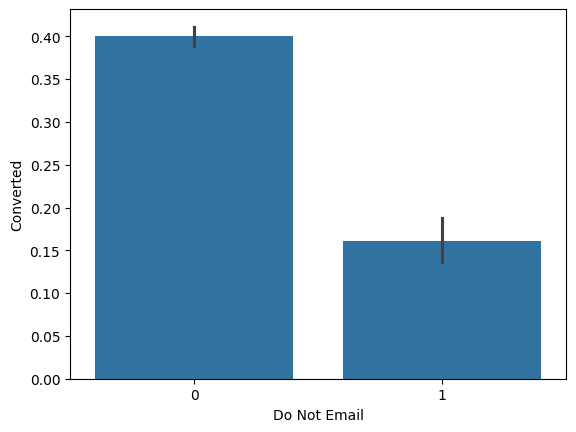

In [53]:
sns.barplot(data = df, x = 'Do Not Email', y = 'Converted')

From the above we can determine that the users that have clicked Yes for 'Do Not Email'have a very low rate of conversion as compared to the ones that have clicked on No.

In [54]:
# Segregation of numerical columns and categorical columns

numerical_cols = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']
categorical_cols = ['Lead Origin', 'Lead Source', 'Last Activity', 'Specialization',
                    'How did you hear about X Education', 'What is your current occupation',
                    'What matters most to you in choosing a course',
                    'City', 'Country']

In [55]:
# using dummies to encode the categorical columns

df = pd.get_dummies(df, columns = categorical_cols, drop_first=True)

In [56]:
# The below columns seem to have a greater probability for data leakage so dropping these

df.drop(columns=['Tags', 'Last Notable Activity'], inplace=True)

In [57]:
# Segregating the target and other variables

y = df.pop('Converted')
X = df

In [58]:
# Segregation into train and test dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42, stratify=y)

In [59]:
# using scaler to optimise the values (only numerical)

scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [60]:
# Checking whether our outputs are correct

X_train[numerical_cols].head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit
8853,-0.695466,-0.883510,-1.082079
1011,-0.294174,-0.743383,-0.625787
5896,-0.093529,1.664581,0.286798
258,-0.294174,-0.048282,-0.169494
2329,0.508409,1.688550,1.655675


In [61]:
# Creating an instance of logistic regression model

model = LogisticRegression(max_iter = 1000, random_state = 42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [62]:
y_pred = model.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print('\n')

print(confusion_matrix(y_test, y_pred))

print('\n')

print(classification_report(y_test, y_pred))

Accuracy: 0.8216630196936543


[[987 145]
 [181 515]]


              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1132
           1       0.78      0.74      0.76       696

    accuracy                           0.82      1828
   macro avg       0.81      0.81      0.81      1828
weighted avg       0.82      0.82      0.82      1828



In [64]:
X_train.columns

Index(['Do Not Email', 'TotalVisits', 'Total Time Spent on Website',
       'Page Views Per Visit', 'Search', 'Magazine', 'Newspaper Article',
       'X Education Forums', 'Newspaper', 'Digital Advertisement',
       ...
       'Country_Sri Lanka', 'Country_Sweden', 'Country_Switzerland',
       'Country_Tanzania', 'Country_Uganda', 'Country_United Arab Emirates',
       'Country_United Kingdom', 'Country_United States', 'Country_Vietnam',
       'Country_unknown'],
      dtype='object', length=136)

In [66]:
# I have basically looked up this VIF automation part in LLM's, have used this to drop unnecessary column and run my model again


from statsmodels.stats.outliers_influence import variance_inflation_factor


def auto_drop_high_vif(df, threshold=5.0):
    """
    Iteratively removes features with a VIF greater than the specified threshold.
    """
    # 1. Cast to float to avoid the boolean object array TypeError
    df_cleaned = df.astype(float).copy()

    # 2. Drop constant columns to prevent NaN/Zero Variance errors
    df_cleaned = df_cleaned.loc[:, df_cleaned.nunique() > 1]

    dropped_features = []

    while True:
        # Calculate VIF for current features
        vif_data = pd.DataFrame()
        vif_data["Feature"] = df_cleaned.columns
        vif_data["VIF"] = [variance_inflation_factor(df_cleaned.values, i)
                           for i in range(df_cleaned.shape[1])]

        # Find the maximum VIF value
        max_vif = vif_data['VIF'].max()

        # Check if the highest VIF is infinity or above the threshold
        if max_vif == np.inf or max_vif > threshold:
            # Identify the feature name with the highest VIF
            feature_to_drop = vif_data.loc[vif_data['VIF'] == max_vif, 'Feature'].iloc[0]

            print(f"Dropping '{feature_to_drop}' (VIF: {max_vif:.2f})")

            # Drop it from our working dataframe
            df_cleaned = df_cleaned.drop(columns=[feature_to_drop])
            dropped_features.append(feature_to_drop)
        else:
            # If the max VIF is acceptable, break the loop
            break

    print("\n--- Feature Elimination Complete ---")
    print(f"Total features dropped: {len(dropped_features)}")

    # Generate final VIF dataframe for display
    final_vif = pd.DataFrame()
    final_vif["Feature"] = df_cleaned.columns
    final_vif["VIF"] = [variance_inflation_factor(df_cleaned.values, i)
                        for i in range(df_cleaned.shape[1])]
    final_vif['VIF'] = round(final_vif['VIF'], 2)
    final_vif = final_vif.sort_values(by="VIF", ascending=False)

    # Return both the cleaned training data and the final VIF summary
    return df_cleaned, final_vif

# --- Run the function ---
# You can change the threshold to 10.0 if you want to be less strict
X_train_selected, final_vif_table = auto_drop_high_vif(X_train, threshold=10.0)

# Display the surviving features and their VIFs
display(final_vif_table)

Dropping 'Newspaper Article' (VIF: inf)
Dropping 'Country_India' (VIF: 2127.02)
Dropping 'What is your current occupation_Unemployed' (VIF: 630.51)
Dropping 'Last Activity_Email Opened' (VIF: 304.37)
Dropping 'What matters most to you in choosing a course_Not Provided' (VIF: 179.92)
Dropping 'How did you hear about X Education_Not Provided' (VIF: 109.00)
Dropping 'Lead Source_Facebook' (VIF: 37.41)
Dropping 'Lead Origin_Lead Add Form' (VIF: 19.09)
Dropping 'Specialization_Not Provided' (VIF: 17.43)
Dropping 'Country_Not Provided' (VIF: 12.85)
Dropping 'Lead Origin_Landing Page Submission' (VIF: 11.36)

--- Feature Elimination Complete ---
Total features dropped: 11


,Feature,VIF
74,City_Not Provided,8.37
12,Lead Source_Google,7.91
11,Lead Source_Direct Traffic,7.33
14,Lead Source_Olark Chat,5.75
8,A free copy of Mastering The Interview,4.50
...,...,...
85,Country_China,1.00
92,Country_Italy,1.00
89,Country_Ghana,1.00
105,Country_Sweden,1.00


In [69]:
# Running my logistic regression model again on new dataset

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [71]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [72]:
y_prob = model.predict_proba(X_test)
y_prob

array([[0.90343385, 0.09656615],
       [0.95911814, 0.04088186],
       [0.04764912, 0.95235088],
       ...,
       [0.74015655, 0.25984345],
       [0.61227273, 0.38772727],
       [0.68298597, 0.31701403]])

In [74]:
lead_score_probability = y_prob[:,1]
lead_score_probability

array([0.09656615, 0.04088186, 0.95235088, ..., 0.25984345, 0.38772727,
       0.31701403])

In [84]:
lead_score = lead_score_probability * 100
lead_score

array([ 9.65661469,  4.08818569, 95.23508764, ..., 25.98434467,
       38.77272659, 31.70140317])

In [77]:
results = pd.DataFrame()

results["Actual Conversion"] = y_test.values

results["Predicted Conversion"] = y_pred

results["Conversion Probability"] = lead_score_probability

results["Lead Score"] = lead_score

In [85]:
# We use the below dataset to identify hot leads

results

,Actual Conversion,Predicted Conversion,Conversion Probability,Lead Score,Hot Lead
0,0,0,0.096566,9.656615,False
1,0,0,0.040882,4.088186,False
2,1,1,0.952351,95.235088,True
3,0,1,0.692381,69.238051,False
4,1,1,0.562383,56.238269,False
...,...,...,...,...,...
1823,0,0,0.100696,10.069582,False
1824,0,0,0.097452,9.745208,False
1825,0,0,0.259843,25.984345,False
1826,0,0,0.387727,38.772727,False


In [78]:
results["Hot Lead"] = results["Lead Score"] >= 80

In [80]:
results['Hot Lead'].head(5)

,Hot Lead
0,False
1,False
2,True
3,False
4,False


In [81]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, lead_score_probability)

print("ROC AUC Score:", auc)

ROC AUC Score: 0.8897911082003168


In [82]:
coefficients = pd.DataFrame()

coefficients["Feature"] = X_train.columns

coefficients["Coefficient"] = model.coef_[0]

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

                                               Feature  Coefficient
33                        Lead Source_Welingak Website     1.797447
118                               Country_Not Provided     1.627754
17                           Lead Origin_Lead Add Form     1.525160
88   What is your current occupation_Working Profes...     1.465488
51                              Last Activity_SMS Sent     1.275577
..                                                 ...          ...
40                     Last Activity_Converted to Lead    -0.991197
16                 Lead Origin_Landing Page Submission    -1.019738
0                                         Do Not Email    -1.207016
90   What matters most to you in choosing a course_...    -1.262850
48               Last Activity_Olark Chat Conversation    -1.356132

[136 rows x 2 columns]
